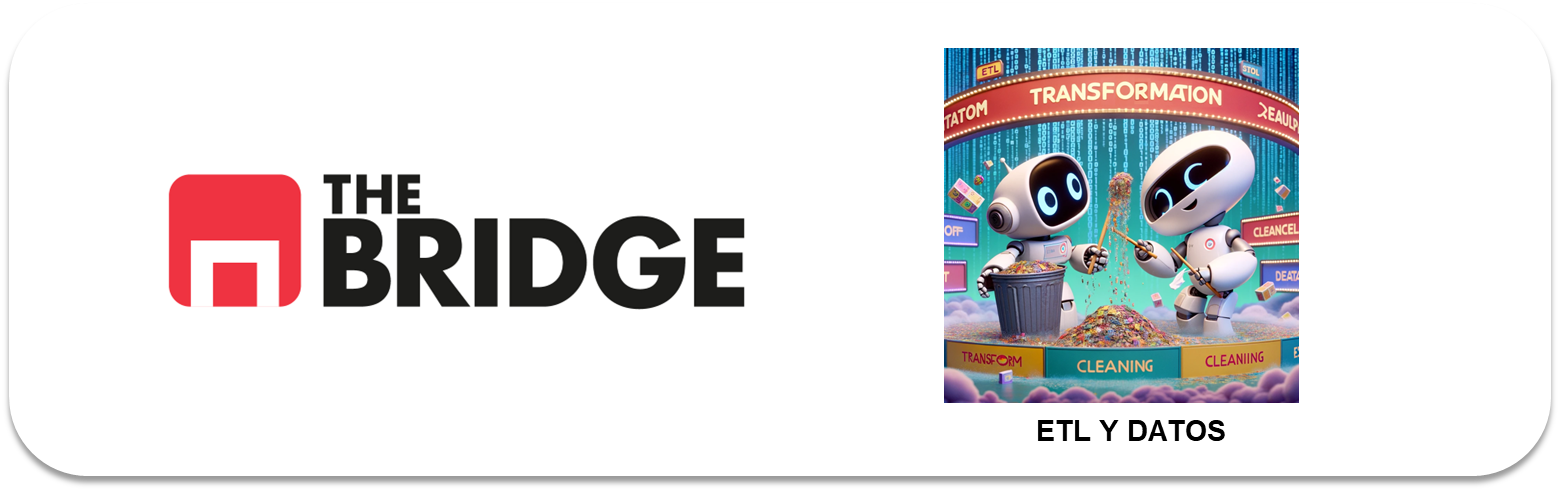

## PRACTICA OBLIGATORIA: **Transformación y Limpieza**

* La práctica obligatoria de esta unidad consiste en cargar un dataset de Netflix y hacer un repaso completo del mismo, limpiando, transformando y creando algunas variables. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

## #0 Carga de datos y primera exploración

In [1]:
import numpy as np
import pandas as pd

df_peliculas = pd.read_csv("data/dataset_netflix_titles.csv")

1. Haz una primera exploración de los datos. Haz una primera visualización de la tabla, muestra la información general, la descripción de las variables numéricas, las columnas y muestra la distribución de datos de tres columnas escogidas por ti.

In [2]:
df_peliculas.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print(f"Dimensiones: {df_peliculas.shape[0]} filas x {df_peliculas.shape[1]} columnas")
df_peliculas.info()

Dimensiones: 8807 filas x 12 columnas
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [4]:
df_peliculas.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [5]:
print("Columnas del dataset:")
print(df_peliculas.columns.tolist())

Columnas del dataset:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


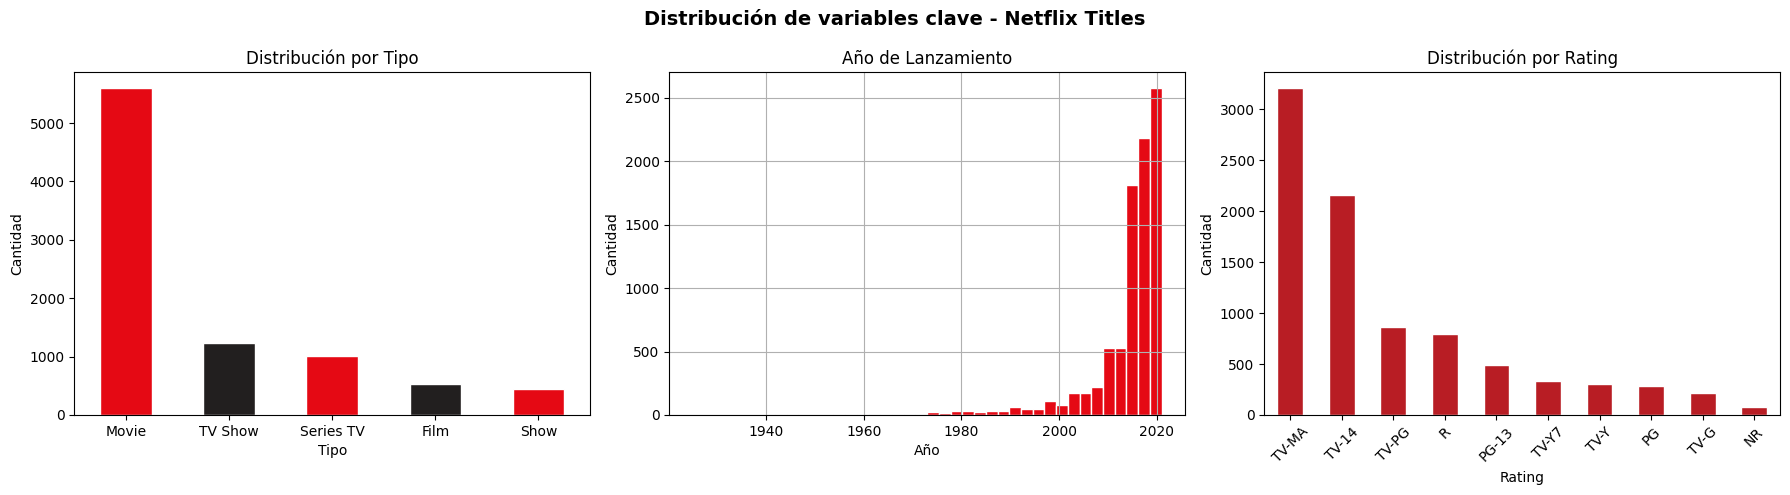

In [8]:
import matplotlib.pyplot as plt  # ← añade esta línea al principio

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distribución de variables clave - Netflix Titles", fontsize=14, fontweight='bold')

# --- Columna 1: type (Movie vs TV Show) ---
df_peliculas['type'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#E50914', '#221F1F'], edgecolor='white'
)
axes[0].set_title("Distribución por Tipo")
axes[0].set_xlabel("Tipo")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis='x', rotation=0)

# --- Columna 2: release_year ---
df_peliculas['release_year'].hist(
    ax=axes[1], bins=40, color='#E50914', edgecolor='white'
)
axes[1].set_title("Año de Lanzamiento")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("Cantidad")

# --- Columna 3: rating ---
df_peliculas['rating'].value_counts().head(10).plot(
    kind='bar', ax=axes[2], color='#B81D24', edgecolor='white'
)
axes[2].set_title("Distribución por Rating")
axes[2].set_xlabel("Rating")
axes[2].set_ylabel("Cantidad")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("exploracion_netflix.png", dpi=150, bbox_inches='tight')
plt.show()

## #1 Duplicados y cardinalidad

1. ¿Existen filas duplicadas?¿Cuántas?

In [9]:
# Número total de filas duplicadas
duplicados = df_peliculas.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

Filas duplicadas: 0


2. Deshazte de las filas duplicadas, si las hubiera. Quédate con las últimas copias.

In [12]:
#nohay
print(f"Filas antes: {len(df_peliculas)}")
print(f"Filas duplicadas: {df_peliculas.duplicated().sum()}")

Filas antes: 8807
Filas duplicadas: 0


In [15]:
# keep='last' → conserva la última aparición de cada duplicado
df_peliculas = df_peliculas.drop_duplicates(keep='last')

print(f"Filas después: {len(df_peliculas)}")
print("Duplicados eliminados correctamente.")


Filas después: 8807
Duplicados eliminados correctamente.


In [14]:
print(f"Duplicados restantes: {df_peliculas.duplicated().sum()}")

Duplicados restantes: 0


3. Ahora que no hay duplicados, tiene sentido calcular la cardinalidad de cada columna. Haz un programa que la obtenga y guarde el resultado en un diccionario con claves el nombre de las columnas y valores la cardinalidad (tal y como la hemos visto en el workout) de cada columna. [Nota: ¿has tenido en cuenta los valores nulos?]

In [16]:
# La cardinalidad = número de valores únicos por columna (sin contar NaN)
cardinalidad = {col: df_peliculas[col].nunique() for col in df_peliculas.columns}

print("Cardinalidad por columna:")
for col, card in cardinalidad.items():
    print(f"  {col}: {card}")

Cardinalidad por columna:
  show_id: 8807
  type: 5
  title: 8807
  director: 4528
  cast: 7692
  country: 748
  date_added: 1767
  release_year: 74
  rating: 17
  duration: 220
  listed_in: 514
  description: 8775


In [17]:
pd.DataFrame.from_dict(cardinalidad, orient='index', columns=['Cardinalidad'])

,Cardinalidad
show_id,8807
type,5
title,8807
director,4528
cast,7692
country,748
date_added,1767
release_year,74
rating,17
duration,220


4. Haz un pequeño programa que recorra el diccionario y nos diga si hay alguna columna que pueda ser un buen índice (cardinalidad = 100%)


In [19]:
# Total de filas del dataframe
total_filas = len(df_peliculas)

# Recorrer el diccionario y detectar columnas con cardinalidad del 100%
print("🔍 Buscando columnas candidatas a índice (cardinalidad = 100%)...\n")

candidatas = []

for col, card in cardinalidad.items():
    porcentaje = (card / total_filas) * 100
    if card == total_filas:
        print(f"✅ '{col}' puede ser un buen índice → cardinalidad: {card}/{total_filas} ({porcentaje:.2f}%)")
        candidatas.append(col)

if not candidatas:
    print("❌ Ninguna columna tiene cardinalidad del 100%.")
else:
    print(f"\n→ Columnas candidatas a índice: {candidatas}")

🔍 Buscando columnas candidatas a índice (cardinalidad = 100%)...

✅ 'show_id' puede ser un buen índice → cardinalidad: 8807/8807 (100.00%)
✅ 'title' puede ser un buen índice → cardinalidad: 8807/8807 (100.00%)

→ Columnas candidatas a índice: ['show_id', 'title']


Bonus: Haz los ejercicios 3 y 4 pero usando un objeto `Series` en vez de un diccionario.

In [20]:
total_filas = len(df_peliculas)

# Filtrar directamente la Series donde cardinalidad == total de filas
candidatas_series = cardinalidad_series[cardinalidad_series == total_filas]

if len(candidatas_series) == 0:
    print("❌ Ninguna columna tiene cardinalidad del 100%.")
else:
    print("✅ Columnas candidatas a índice (cardinalidad = 100%):\n")
    print(candidatas_series)

NameError: name 'cardinalidad_series' is not defined

## #2 Limpieza y transformación (I)

El primer paso en la limpieza es intentar detectar que campos están "sucios", una posible guía podría ser, encontrar:  
* Campos numéricos inconsistentes (el típico campo con la coma y el punto decimal mezclado, o con formatos numéricos combinados)  
* Campos con valores inconsistentes (por ejemplo aparecen valores que no tienen relación con la columna en la que están porque están mal colocados, porque se han incluido por error, valores medidos en una unidad frente a otros medidos en otra)  
* Campos con valores que son iguales pero están representados de formas diferentes (por ejemplo un actor que unas veces aparece con el nombre en un orden y otras veces con el nombre en otro, o el nombre de un país como USA que aparezca como EEUU otras veces, o cadenas que tienen espacios al principio y al final y Python las considera diferentes: " Clint Eastwood " y "Clint Eastwood").  


Vamos a hacer un pequeño análisis siguiendo las pautas anteriores pero sin profundizar en ellas, en tu EDA sí que tendrás que hacerlo. Para ello nos vamos a centrar en los campos con cardinalidad menor que un 10% (el resto requiere un análsis mucho más exahustivo que se nos va fuera del alcance de la práctica, pero, repito en tu EDA tendrás que hacerlo)

1. Antes de centrarnos en esos campos, quita los espacios en blanco que pueda haber antes o después de cada valor string. (utiliza el método de cadenas de pandas, `strip`). Por ejemplo (como guía pero no como única solución) recorre con un for el nombre de las columnas y ve aplicando el método columna a columna. Pero puedes hacerlo como tú quieras, claro.

In [21]:
# Recorremos solo las columnas de tipo object (strings)
for col in df_peliculas.columns:
    if df_peliculas[col].dtype == 'object':
        df_peliculas[col] = df_peliculas[col].str.strip()

print("Espacios eliminados en todas las columnas string.")

Espacios eliminados en todas las columnas string.


In [22]:
# Comprobamos con un ejemplo antes/después
# (antes del strip habría espacios, ahora no debería haberlos)
df_peliculas.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [26]:
# Guardamos la cardinalidad ANTES de hacer el strip
cardinalidad_antes = df_peliculas.nunique()

In [28]:
for col in df_peliculas.columns:
    if df_peliculas[col].dtype == 'object':
        df_peliculas[col] = df_peliculas[col].str.strip()

print("Strip aplicado.")

Strip aplicado.


Bonus: ¿Se te ocurre alguna forma rápida, que no necesariamente completa, de ver si ha afectado en algo esta operación?

In [31]:
cardinalidad_despues = df_peliculas.nunique()

diferencias = cardinalidad_antes - cardinalidad_despues

print("Columnas afectadas por el strip:")
print(diferencias[diferencias > 0])

if diferencias.sum() == 0:
    print("Ninguna columna fue afectada. No había espacios problemáticos.")

Columnas afectadas por el strip:
Series([], dtype: int64)
Ninguna columna fue afectada. No había espacios problemáticos.


2. Lista los campos con cardinalidad menor a 10%

In [34]:
total_filas = len(df_peliculas)

# Filtrar columnas cuya cardinalidad sea menor al 10% del total de filas
umbral = 0.10 * total_filas

baja_cardinalidad = cardinalidad_despues[cardinalidad_despues < umbral]

print(f"Total filas: {total_filas}")
print(f"Umbral 10%: {umbral:.0f} valores únicos\n")
print("Columnas con cardinalidad < 10%:")
print(baja_cardinalidad)

Total filas: 8807
Umbral 10%: 881 valores únicos

Columnas con cardinalidad < 10%:
type              5
country         748
release_year     74
rating           17
duration        220
listed_in       514
dtype: int64


In [35]:
df_baja_card = pd.DataFrame({
    'Cardinalidad': baja_cardinalidad,
    'Porcentaje (%)': (baja_cardinalidad / total_filas * 100).round(2)
}).sort_values('Porcentaje (%)')

df_baja_card

,Cardinalidad,Porcentaje (%)
type,5,0.06
rating,17,0.19
release_year,74,0.84
duration,220,2.50
listed_in,514,5.84
country,748,8.49


3. Para los campos que hayas obtenido, muestra su distribución de valores, sus valores únicos y determina si crees que se puede o debe hacer alguna acción de limpieza o transformación directa. No le des muchas vueltas.

In [36]:
for col in baja_cardinalidad.index:
    print(f"\n{'='*50}")
    print(f"COLUMNA: {col}")
    print(f"Valores únicos ({baja_cardinalidad[col]}):")
    print(sorted(df_peliculas[col].dropna().unique()))
    print(f"\nDistribución:")
    print(df_peliculas[col].value_counts(dropna=False))


COLUMNA: type
Valores únicos (5):
['Film', 'Movie', 'Series TV', 'Show', 'TV Show']

Distribución:
type
Movie        5597
TV Show      1231
Series TV    1004
Film          534
Show          441
Name: count, dtype: int64

COLUMNA: country
Valores únicos (748):
[', France, Algeria', ', South Korea', 'Argentina', 'Argentina, Brazil, France, Poland, Germany, Denmark', 'Argentina, Chile', 'Argentina, Chile, Peru', 'Argentina, France', 'Argentina, France, United States, Germany, Qatar', 'Argentina, Italy', 'Argentina, Spain', 'Argentina, United States', 'Argentina, United States, Mexico', 'Argentina, Uruguay, Serbia', 'Argentina, Uruguay, Spain, France', 'Argentina, Venezuela', 'Australia', 'Australia, Armenia, Japan, Jordan, Mexico, Mongolia, New Zealand, Philippines, South Africa, Sweden, United States, Uruguay', 'Australia, Canada', 'Australia, France', 'Australia, France, Ireland', 'Australia, Germany', 'Australia, India', 'Australia, Iraq', 'Australia, New Zealand', 'Australia, New Zea

C:\Users\claud\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


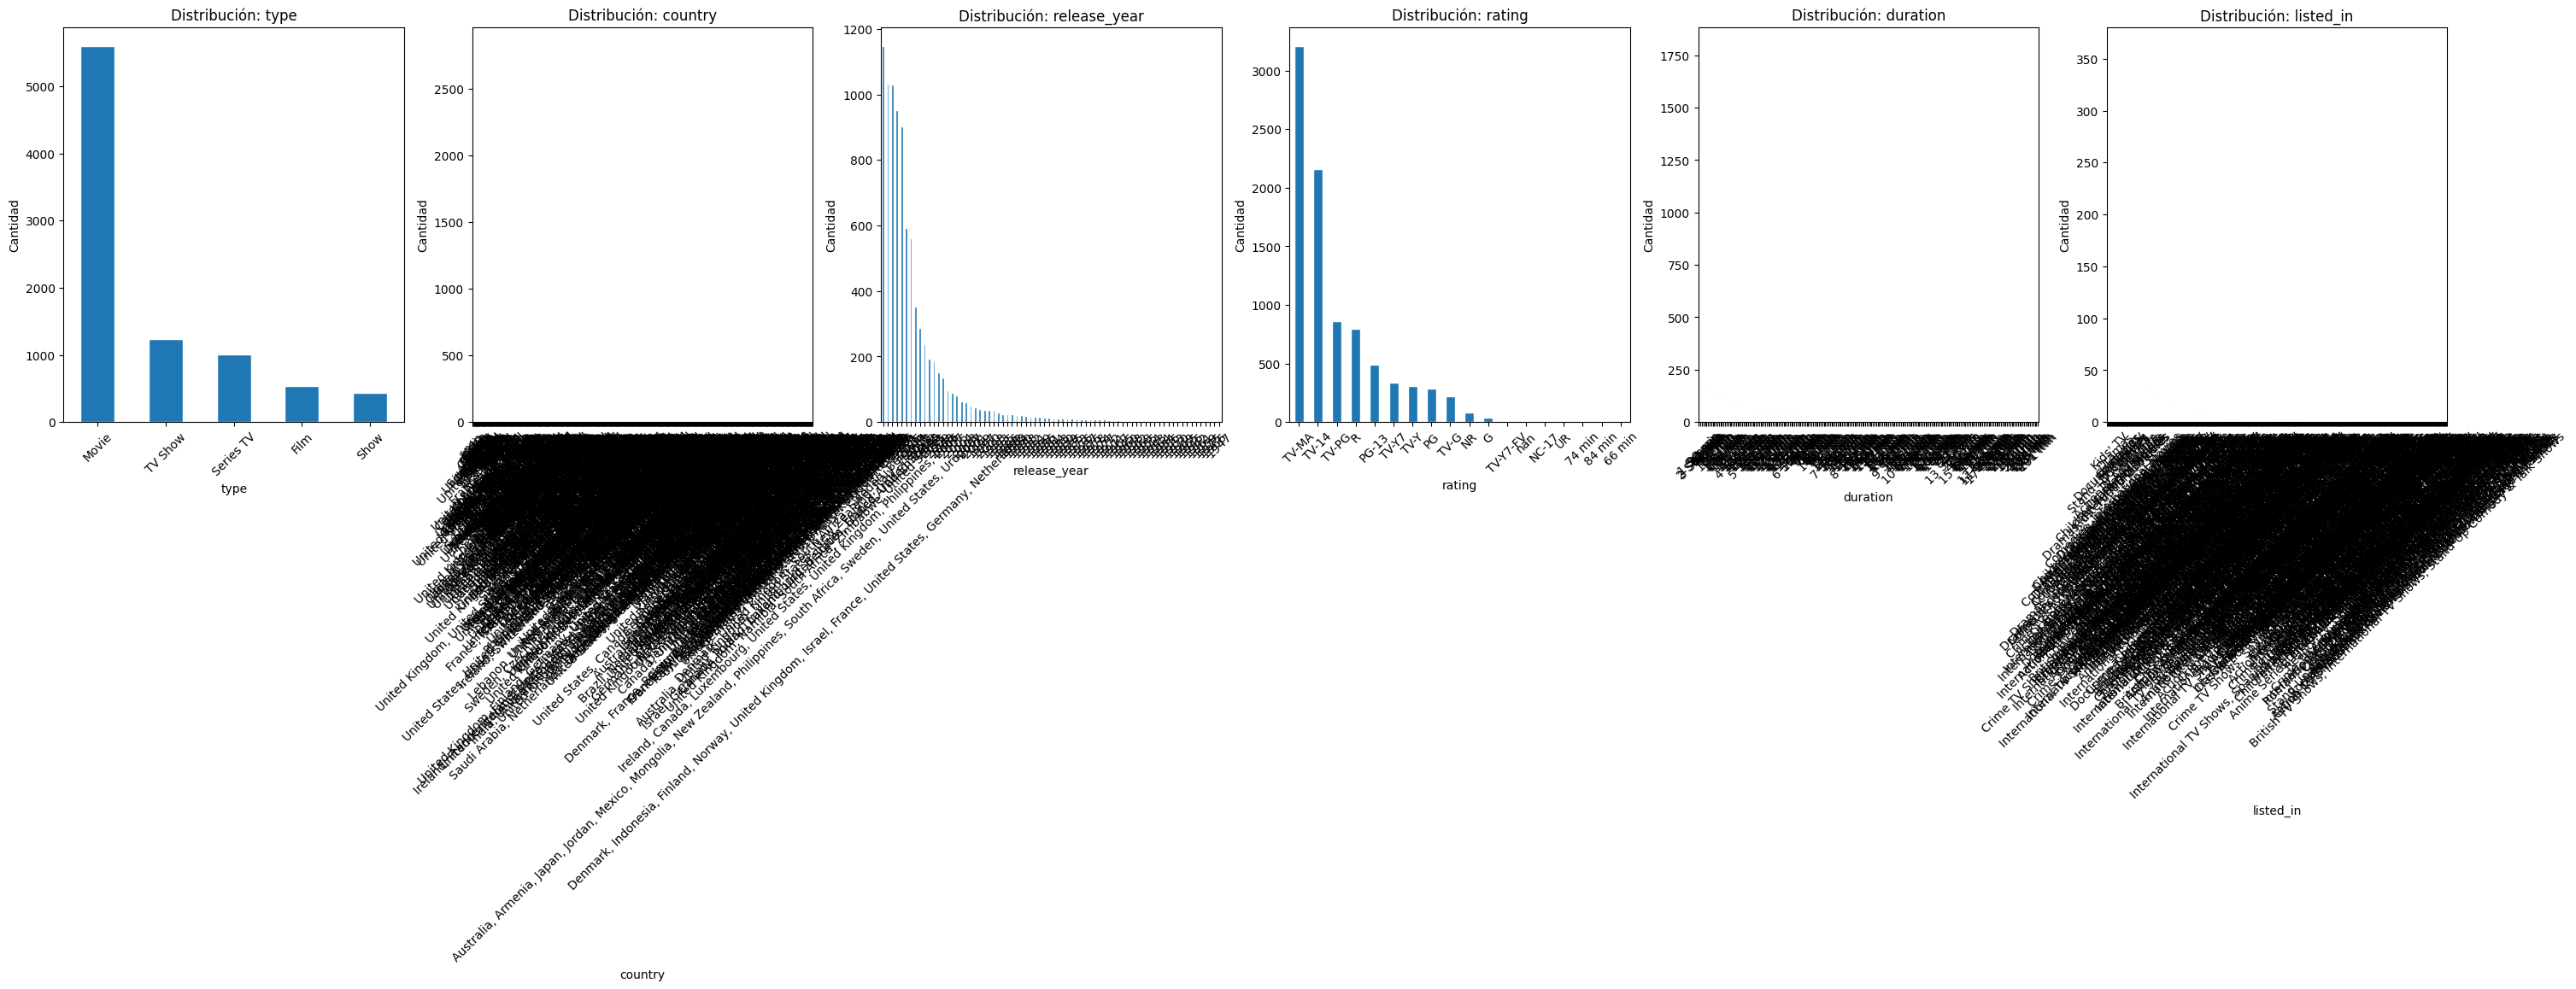

In [38]:
import matplotlib.pyplot as plt

n_cols = len(baja_cardinalidad)

# Usar constrained_layout=True en lugar de tight_layout()
fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 6),
                         constrained_layout=True)

for i, col in enumerate(baja_cardinalidad.index):
    df_peliculas[col].value_counts(dropna=False).plot(
        kind='bar', ax=axes[i], edgecolor='white'
    )
    axes[i].set_title(f"Distribución: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Cantidad")
    axes[i].tick_params(axis='x', rotation=45)

plt.show()

4. Limpia o simplifica/transforma dos de los campos detectados en 3, si hay al menos dos, si no, uno. Para ello puedes:  
4.1 Cualquier agrupa los valores de los campos tipo categoría con categorías similares que se llamen distinto.  
4.2 Quita valores extraños o que no correspondan. Conviertelos a "", y luego busca un valor para sustituirlos.

In [39]:
# Identificar valores que NO son ratings (los que contienen 'min')
valores_raros_rating = df_peliculas[df_peliculas['rating'].str.contains('min', na=False)]['rating'].unique()
print("Valores extraños en rating:", valores_raros_rating)

Valores extraños en rating: <StringArray>
['74 min', '84 min', '66 min']
Length: 3, dtype: str


In [40]:
import numpy as np

# Paso 1: convertir valores extraños a NaN
df_peliculas['rating'] = df_peliculas['rating'].apply(
    lambda x: np.nan if isinstance(x, str) and 'min' in x else x
)

# Paso 2: sustituir NaN por la moda (el valor más frecuente)
moda_rating = df_peliculas['rating'].mode()[0]
df_peliculas['rating'] = df_peliculas['rating'].fillna(moda_rating)

print(f"NaN sustituidos por la moda: '{moda_rating}'")
print(df_peliculas['rating'].value_counts())

NaN sustituidos por la moda: 'TV-MA'
rating
TV-MA       3214
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


In [41]:
# Las películas tienen formato "90 min" y las series "2 Seasons"
print(df_peliculas[['type', 'duration']].drop_duplicates().head(10))

       type   duration
0     Movie     90 min
1   TV Show  2 Seasons
2   TV Show   1 Season
6     Movie     91 min
7      Film    125 min
8      Show  9 Seasons
9     Movie    104 min
12    Movie    127 min
15     Show  4 Seasons
16    Movie     67 min


In [42]:
# Extraer minutos solo para películas
df_peliculas['duration_mins'] = df_peliculas['duration'].apply(
    lambda x: int(x.split(' ')[0]) if isinstance(x, str) and 'min' in x else np.nan
)

# Extraer temporadas solo para series
df_peliculas['duration_seasons'] = df_peliculas['duration'].apply(
    lambda x: int(x.split(' ')[0]) if isinstance(x, str) and 'Season' in x else np.nan
)

# Verificar resultado
print(df_peliculas[['type', 'duration', 'duration_mins', 'duration_seasons']].head(10))

      type   duration  duration_mins  duration_seasons
0    Movie     90 min           90.0               NaN
1  TV Show  2 Seasons            NaN               2.0
2  TV Show   1 Season            NaN               1.0
3  TV Show   1 Season            NaN               1.0
4  TV Show  2 Seasons            NaN               2.0
5  TV Show   1 Season            NaN               1.0
6    Movie     91 min           91.0               NaN
7     Film    125 min          125.0               NaN
8     Show  9 Seasons            NaN               9.0
9    Movie    104 min          104.0               NaN


In [43]:
print("Películas con duración en mins:")
print(df_peliculas[df_peliculas['type'] == 'Movie']['duration_mins'].describe())

print("\nSeries con número de temporadas:")
print(df_peliculas[df_peliculas['type'] == 'TV Show']['duration_seasons'].describe())

Películas con duración en mins:
count    5594.000000
mean       99.655166
std        28.475321
min         3.000000
25%        86.000000
50%        98.000000
75%       115.000000
max       312.000000
Name: duration_mins, dtype: float64

Series con número de temporadas:
count    1231.000000
mean        1.726239
std         1.479602
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        15.000000
Name: duration_seasons, dtype: float64


5. Convierte o cambia el tipo de la columna con fechas en strings a un tipo datetime. La columna que son solo años es mejor dejarla como integer, porque se opera muy fácil así. Tendrás que analizar los argumentos de pd.datetime y jugar con ellos para poder conseguirlo.

In [44]:
# Primero revisamos cómo están las fechas para saber el formato
print(df_peliculas['date_added'].dropna().head(10))
print(f"\nTipo actual: {df_peliculas['date_added'].dtype}")

0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
5    September 24, 2021
6    September 24, 2021
7    September 24, 2021
8    September 24, 2021
9    September 24, 2021
Name: date_added, dtype: str

Tipo actual: str


In [45]:
# Formato: "September 25, 2021" → %B %d, %Y
# %B = nombre del mes completo en inglés
# %d = día con o sin cero delante
# %Y = año con 4 dígitos
# errors='coerce' convierte los valores que no puedan parsearse en NaT (equivalente a NaN para fechas)

df_peliculas['date_added'] = pd.to_datetime(
    df_peliculas['date_added'],
    format='%B %d, %Y',
    errors='coerce'
)

print(f"Tipo nuevo: {df_peliculas['date_added'].dtype}")
print(df_peliculas['date_added'].head(10))

Tipo nuevo: datetime64[us]
0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
5   2021-09-24
6   2021-09-24
7   2021-09-24
8   2021-09-24
9   2021-09-24
Name: date_added, dtype: datetime64[us]


In [46]:
print(f"Valores NaT tras conversión: {df_peliculas['date_added'].isna().sum()}")

Valores NaT tras conversión: 98


In [47]:
# release_year debe quedarse como int (ya lo es, solo lo confirmamos)
print(f"Tipo de release_year: {df_peliculas['release_year'].dtype}")
print(df_peliculas['release_year'].head())

Tipo de release_year: int64
0    2020
1    2021
2    2021
3    2021
4    2021
Name: release_year, dtype: int64


## #3 Tratamiento de Missings/Nulos

Es hora de tratar los nulos. Así que habrá que identificarlos para empezar.

1. Haz una lista con las columnas que contienen valores nulos. Obtenla a "mano" mirando la salid del método info o bien haz un programa que las obtenga de forma automática.

In [50]:
# Forma automática: isnull().sum() filtrando solo las que tienen nulos
nulos = df_peliculas.isnull().sum()
columnas_con_nulos = nulos[nulos > 0]

print("Columnas con valores nulos:")
print(columnas_con_nulos)

Columnas con valores nulos:
director            2634
cast                 825
country              831
date_added            98
duration               3
duration_mins       2679
duration_seasons    6131
dtype: int64


In [51]:
total_filas = len(df_peliculas)

df_nulos = pd.DataFrame({
    'Nulos': nulos[nulos > 0],
    'Porcentaje (%)': (nulos[nulos > 0] / total_filas * 100).round(2)
}).sort_values('Porcentaje (%)', ascending=False)

df_nulos

,Nulos,Porcentaje (%)
duration_seasons,6131,69.62
duration_mins,2679,30.42
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,98,1.11
duration,3,0.03


2. Obten el porcentaje de valores nulos para cada una de las columnas.

In [52]:
total_filas = len(df_peliculas)

df_nulos = pd.DataFrame({
    'Nulos': nulos[nulos > 0],
    'Porcentaje (%)': (nulos[nulos > 0] / total_filas * 100).round(2)
}).sort_values('Porcentaje (%)', ascending=False)

df_nulos

,Nulos,Porcentaje (%)
duration_seasons,6131,69.62
duration_mins,2679,30.42
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,98,1.11
duration,3,0.03


3. Corrige de la mejor manera que se te ocurra las dos columnas con menor porcentajes de nulos.

In [53]:
# Las 2 columnas con menor porcentaje de nulos
dos_menos_nulos = df_nulos.sort_values('Porcentaje (%)').head(2)
print("Las 2 columnas con menos nulos:")
print(dos_menos_nulos)

Las 2 columnas con menos nulos:
            Nulos  Porcentaje (%)
duration        3            0.03
date_added     98            1.11


In [54]:
# duration tiene muy pocos nulos (~3)
# La mejor estrategia: rellenar con la moda según el tipo (Movie o TV Show)
# porque "90 min" y "1 Season" no son intercambiables

moda_duration_movie = df_peliculas[df_peliculas['type'] == 'Movie']['duration'].mode()[0]
moda_duration_serie = df_peliculas[df_peliculas['type'] == 'TV Show']['duration'].mode()[0]

df_peliculas['duration'] = df_peliculas.apply(
    lambda row: moda_duration_movie if pd.isna(row['duration']) and row['type'] == 'Movie'
    else (moda_duration_serie if pd.isna(row['duration']) and row['type'] == 'TV Show'
    else row['duration']),
    axis=1
)

print(f"Nulos en duration tras corrección: {df_peliculas['duration'].isna().sum()}")

Nulos en duration tras corrección: 0


In [55]:
# rating tiene muy pocos nulos (~4)
# Al ser una variable categórica, la moda es la mejor opción

moda_rating = df_peliculas['rating'].mode()[0]
df_peliculas['rating'] = df_peliculas['rating'].fillna(moda_rating)

print(f"Nulos en rating tras corrección: {df_peliculas['rating'].isna().sum()}")
print(f"Valor usado para imputar: '{moda_rating}'")

Nulos en rating tras corrección: 0
Valor usado para imputar: 'TV-MA'


In [56]:
print(df_peliculas[['duration', 'rating']].isna().sum())

duration    0
rating      0
dtype: int64


4. En un caso como este, que no hay apenas valores numéricos y las columnas con nulos no son categóricas, es mejor o deshacerse de los nulos o bien simplemente marcarlos pero convertidos a un valor más manejable y del tipo del resto de valores de la columna en la que aparecen. Por eso cambia los nulos en las columnas que no hayas tratado en el apartado anterior por "UNK" o por "".

In [57]:
# Comprobamos qué columnas siguen teniendo nulos
nulos_restantes = df_peliculas.isnull().sum()
columnas_pendientes = nulos_restantes[nulos_restantes > 0].index.tolist()

print("Columnas con nulos pendientes de tratar:")
print(columnas_pendientes)

Columnas con nulos pendientes de tratar:
['director', 'cast', 'country', 'date_added', 'duration_mins', 'duration_seasons']


In [59]:
# Reemplazar NaN por "UNK" en las columnas de tipo object que aún tienen nulos
for col in columnas_pendientes:
    if df_peliculas[col].dtype == 'object':
        df_peliculas[col] = df_peliculas[col].fillna('UNK')

print("Nulos sustituidos por 'UNK'.")

Nulos sustituidos por 'UNK'.


In [60]:
print("Nulos restantes tras la limpieza:")
print(df_peliculas.isnull().sum())

Nulos restantes tras la limpieza:
show_id                0
type                   0
title                  0
director            2634
cast                 825
country              831
date_added            98
release_year           0
rating                 0
duration               0
listed_in              0
description            0
duration_mins       2679
duration_seasons    6131
dtype: int64


5. Comprueba ahora que no hemos generado duplicados, si existiesen borralos y quedate la primera ocurrencia.

In [61]:
duplicados = df_peliculas.duplicated().sum()
print(f"Duplicados generados tras la limpieza: {duplicados}")

Duplicados generados tras la limpieza: 0


In [63]:
if duplicados > 0:
    df_peliculas = df_peliculas.drop_duplicates(keep='first')
    print(f"Duplicados eliminados. Filas restantes: {len(df_peliculas)}")
else:
    print("No hay duplicados. El dataset está limpio.")

No hay duplicados. El dataset está limpio.


In [64]:
print(f"Shape final: {df_peliculas.shape}")
print(f"Nulos restantes: {df_peliculas.isnull().sum().sum()}")
print(f"Duplicados: {df_peliculas.duplicated().sum()}")

Shape final: (8807, 14)
Nulos restantes: 13198
Duplicados: 0


## #4 Generación de nuevos datos

Para terminar de hacer nuestro procesado, intentemos enriquecer el dataset y obtener alguna información adicional.

1. Separa el dataset en dos dataframes,uno de películas y otro de series. A veces aunque los datos parecen de la misma naturaleza, puede ser bueno separarlos para trabajar con ellos de forma independiente.

In [66]:
# Separar por el valor de la columna 'type'
df_movies = df_peliculas[df_peliculas['type'] == 'Movie'].copy()
df_shows  = df_peliculas[df_peliculas['type'] == 'TV Show'].copy()

print(f"Películas:  {df_movies.shape[0]} filas x {df_movies.shape[1]} columnas")
print(f"TV Shows:   {df_shows.shape[0]} filas x {df_shows.shape[1]} columnas")
print(f"Total:      {df_movies.shape[0] + df_shows.shape[0]} filas (coincide con el original: {len(df_peliculas)})")

Películas:  5597 filas x 14 columnas
TV Shows:   1231 filas x 14 columnas
Total:      6828 filas (coincide con el original: 8807)


2. Ahora además podemos sacarle más provecho a algunos campos, por ejemplo duration. Muestra la distribución de valores para cada dataframe del campo "duration".

In [67]:
print("Distribución de duration en PELÍCULAS:")
print(df_movies['duration'].value_counts().head(20))

Distribución de duration en PELÍCULAS:
duration
90 min     137
97 min     133
91 min     132
94 min     130
93 min     128
95 min     123
96 min     119
92 min     118
102 min    115
88 min     110
98 min     109
99 min     105
101 min    104
103 min    102
104 min    101
106 min     99
100 min     98
86 min      95
89 min      92
110 min     88
Name: count, dtype: int64


In [69]:
print("Distribución de duration en SERIES:")
print(df_shows['duration'].value_counts())

Distribución de duration en SERIES:
duration
1 Season      833
2 Seasons     186
3 Seasons      98
4 Seasons      50
5 Seasons      26
6 Seasons      11
8 Seasons       9
7 Seasons       9
9 Seasons       4
10 Seasons      2
15 Seasons      1
11 Seasons      1
13 Seasons      1
Name: count, dtype: int64


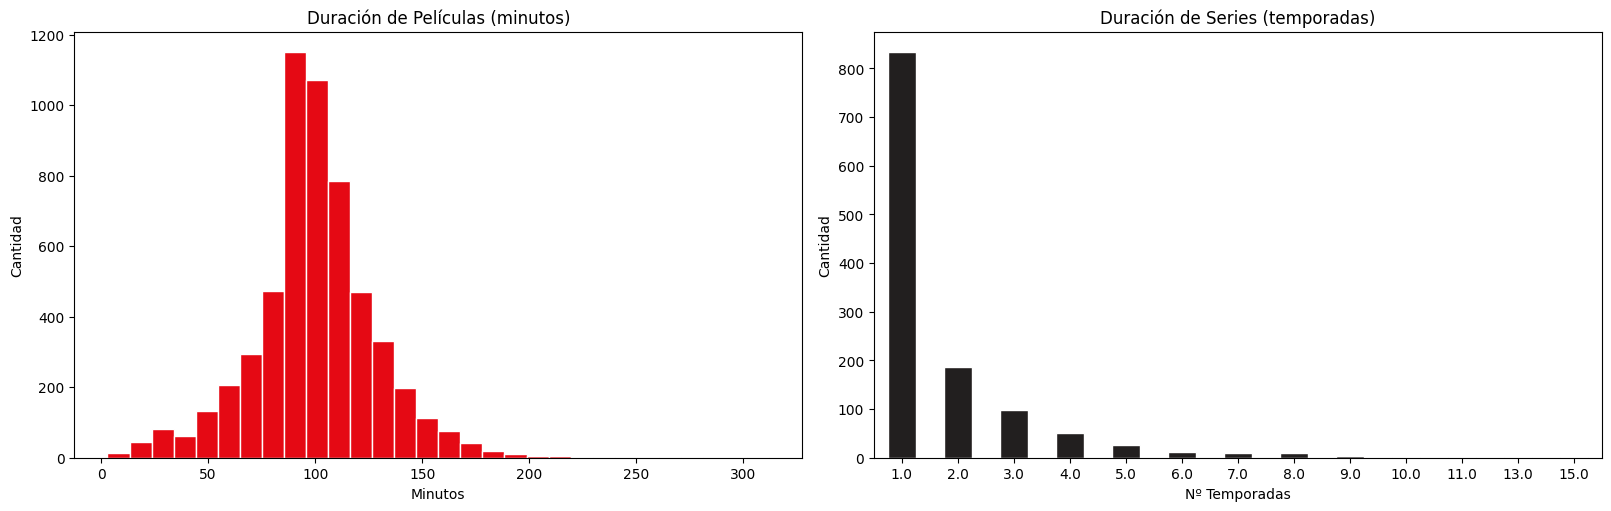

In [70]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

# Películas: histograma con minutos numéricos
df_movies['duration_mins'].dropna().plot(
    kind='hist', bins=30, ax=axes[0],
    color='#E50914', edgecolor='white'
)
axes[0].set_title("Duración de Películas (minutos)")
axes[0].set_xlabel("Minutos")
axes[0].set_ylabel("Cantidad")

# Series: barras con número de temporadas
df_shows['duration_seasons'].dropna().value_counts().sort_index().plot(
    kind='bar', ax=axes[1],
    color='#221F1F', edgecolor='white'
)
axes[1].set_title("Duración de Series (temporadas)")
axes[1].set_xlabel("Nº Temporadas")
axes[1].set_ylabel("Cantidad")
axes[1].tick_params(axis='x', rotation=0)

plt.show()

3. Convierte los valores de "duration" en cada dataframe a valores numéricos y cambia en el de las series el nombre por uno más representativo. Se valorará el emplear una expresión regular para obtener la información.

In [78]:
print("Columnas en df_movies:")
print(df_movies.columns.tolist())

Columnas en df_movies:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'duration', 'duration_seasons']


In [79]:
# Reconstruir df_movies y df_shows limpios desde df_peliculas
df_movies = df_peliculas[df_peliculas['type'] == 'Movie'].copy()
df_shows  = df_peliculas[df_peliculas['type'] == 'TV Show'].copy()

# Películas: extraer minutos de la columna 'duration' original con regex
df_movies['duration'] = df_movies['duration'].astype(str).str.extract(r'(\d+)').astype(float)

# Series: extraer temporadas y renombrar
df_shows['num_seasons'] = df_shows['duration'].astype(str).str.extract(r'(\d+)').astype(float)
df_shows = df_shows.drop(columns=['duration'])

# Verificar
print(f"Tipo duration en películas: {df_movies['duration'].dtype}")
print(df_movies['duration'].head())

print(f"\nTipo num_seasons en series: {df_shows['num_seasons'].dtype}")
print(df_shows['num_seasons'].head())

Tipo duration en películas: float64
0      90.0
6      91.0
9     104.0
12    127.0
13     91.0
Name: duration, dtype: float64

Tipo num_seasons en series: float64
1    2.0
2    1.0
3    1.0
4    2.0
5    1.0
Name: num_seasons, dtype: float64


4. BONUS: Crea un campo "Posible_Secuela" en el dataset de películas con valor a False por defecto. Intenta (con expresiones regulares si es posible) hacer una función que aplicada (con apply) a un título determine si es una posible secuela o no. Emplea la función (con apply) para rellenar el campo "Posible_Secuela". Nota: No hace falta que sea infalible,ni que las cace todas sino que tenga una lógica defendible, piensa en la forma que normalmente tienen las secuelas, por ejemplo la de Terminator.m..